Контрольні запитання та відповіді 

Чим відрізняється те, що гарантує закон великих чисел, від того, що гарантує центральна гранична теорема?

Закон великих чисел (ЗВЧ) відповідає на запитання "куди прямує вибіркове середнє $\bar{x}$" — воно згортається і прямує до істинного теоретичного середнього генеральної сукупності зі зростанням $n$.Центральна гранична теорема (ЦГТ) відповідає на запитання "яку форму і розкид має вибірковий розподіл $\bar{x}$" — вона гарантує, що цей розподіл стає нормальним (дзвоноподібним) незалежно від форми вихідної сукупності.

Чому в цій практиці вихідний розподіл обрано сильно скошеним, а не одразу нормальним?

Щоб наочно продемонструвати силу Центральної граничної теореми: вона працює навіть тоді, коли самі дані розподілені ненормально (як асиметричний час очікування чи покупок). Якби ми взяли одразу нормальний розподіл, ми б не побачили ефекту «перетворення» скошеної форми на симетричний дзвін для $\bar{x}$.

Чому стандартна похибка зменшується пропорційно $\sqrt{n}$, а не $n$?

Це випливає з математичних властивостей дисперсії для суми/середнього незалежних випадкових величин. Практично це означає «закон убуваючої віддачі»: кожна додаткова одиниця даних дає все менший приріст точності, і щоб скоротити похибку вдвічі, обсяг вибірки потрібно збільшити не в 2, а в 4 рази.

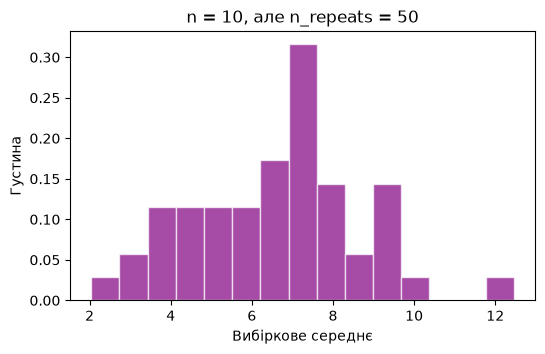

In [5]:
n_repeats_small = 50
means_small_repeats = rng.exponential(scale=true_mean, size=(n_repeats_small, 10)).mean(axis=1)

plt.figure(figsize=(6, 3.5))
plt.hist(means_small_repeats, bins=15, density=True, color="purple", edgecolor="white", alpha=0.7)
plt.title(f"n = 10, але n_repeats = {n_repeats_small}")
plt.xlabel("Вибіркове середнє")
plt.ylabel("Густина")
plt.show()

In [4]:
se_25 = true_mean / np.sqrt(25)
se_100 = true_mean / np.sqrt(100)

print(f"SE для n = 25:  {se_25:.4f}")
print(f"SE для n = 100: {se_100:.4f}")
print(f"Співвідношення (SE_25 / SE_100): {se_25 / se_100:.2f}")

SE для n = 25:  1.3333
SE для n = 100: 0.6667
Співвідношення (SE_25 / SE_100): 2.00


In [3]:
n_list = [10, 30, 100, 300]
print(f"{'n':<6} | {'Теоретична SE':<15} | {'Виміряна std':<15}")
print("-" * 42)

for n in n_list:

    se_theory = true_mean / np.sqrt(n)
    
    simulated_means = rng.exponential(scale=true_mean, size=(10_000, n)).mean(axis=1)
    se_simulated = simulated_means.std()
    
    print(f"{n:<6} | {se_theory:<15.4f} | {se_simulated:<15.4f}")

n      | Теоретична SE   | Виміряна std   
------------------------------------------
10     | 2.1082          | 2.1021         
30     | 1.2172          | 1.2204         
100    | 0.6667          | 0.6683         
300    | 0.3849          | 0.3854         


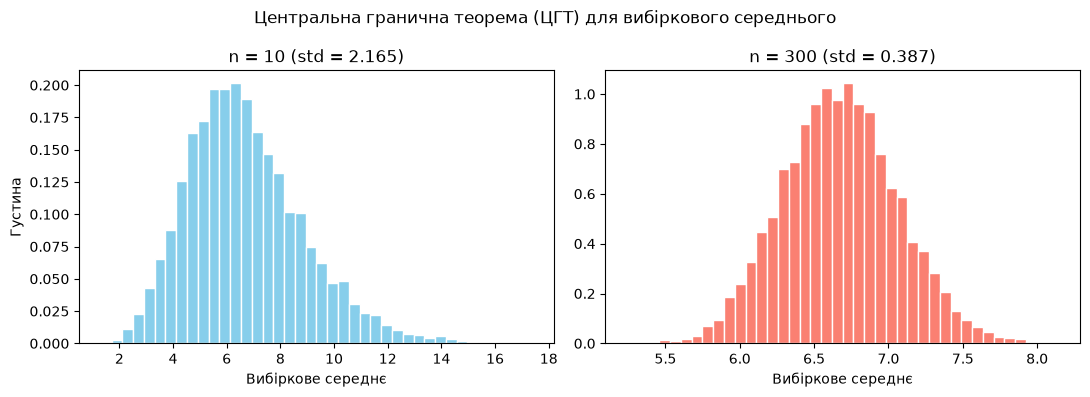

In [2]:
n_repeats = 10_000

means_n10 = rng.exponential(scale=true_mean, size=(n_repeats, 10)).mean(axis=1)
means_n300 = rng.exponential(scale=true_mean, size=(n_repeats, 300)).mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(means_n10, bins=40, density=True, color="skyblue", edgecolor="white")
axes[0].set_title(f"n = 10 (std = {means_n10.std():.3f})")
axes[0].set_xlabel("Вибіркове середнє")
axes[0].set_ylabel("Густина")

axes[1].hist(means_n300, bins=40, density=True, color="salmon", edgecolor="white")
axes[1].set_title(f"n = 300 (std = {means_n300.std():.3f})")
axes[1].set_xlabel("Вибіркове середнє")

plt.suptitle("Центральна гранична теорема (ЦГТ) для вибіркового середнього")
plt.tight_layout()
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(3)

lam = 0.15
true_mean = 1 / lam  # 6.666...
print(f"Теоретичне середнє E[X]: {true_mean:.4f}\n")

n_values = [5, 50, 500, 20_000]
for n in n_values:
    sample = rng.exponential(scale=true_mean, size=n)
    sample_mean = sample.mean()
    abs_diff = abs(sample_mean - true_mean)
    print(f"n = {n:5d} | Вибіркове середнє: {sample_mean:6.3f} | Абсолютна різниця: {abs_diff:6.3f}")

Теоретичне середнє E[X]: 6.6667

n =     5 | Вибіркове середнє:  5.924 | Абсолютна різниця:  0.743
n =    50 | Вибіркове середнє:  7.002 | Абсолютна різниця:  0.335
n =   500 | Вибіркове середнє:  6.965 | Абсолютна різниця:  0.298
n = 20000 | Вибіркове середнє:  6.647 | Абсолютна різниця:  0.020
